# Lunar Lander

## Approach 1: Double Deep Q-learning (DDQL)

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
from torch.nn import Linear, ReLU, Sequential, Module, Softmax
from torch.distributions.categorical import Categorical
from collections import deque
import tqdm
import matplotlib.pyplot as plt
from gymnasium.vector import VectorEnv
from torch._prims_common import DeviceLikeType

In [2]:
class QNetwork(torch.nn.Module):
  def __init__(self, input_dim: int, output_dim: int) -> None:
    super().__init__()
    self.nn = Sequential(
      Linear(input_dim, 128),
      ReLU(),
      Linear(128, 128),
      ReLU(),
      Linear(128, output_dim)
    )

  def forward(self, x):
    return self.nn(x)

class ReplayBuffer:
  def __init__(self, batch_size: int, buffer_size: int) -> None:
    self.batch_size = batch_size
    self.buffer = deque(maxlen=buffer_size)

  def push(self, state, action, reward, next_state, done):
    self.buffer.append((state, action, reward, next_state, done))

  def sample(self):
    indices = np.random.randint(0, len(self.buffer), size=self.batch_size)
    batch = [self.buffer[i] for i in indices]
    states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
    return states, actions, rewards, next_states, dones
  def __len__(self):
      return len(self.buffer)

In [3]:
class DQL:
  def __init__(self, observation_space_size: int, action_space_size: int, epsilon = 1, epsilon_decay = 0.001, min_epsilon = 0.08, batch_size: int = 64, buffer_size: int = 100_000, gamma: float = 0.99, target_update_freq = 1000, device: str = "mps") -> None:
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_decay = epsilon_decay
    self.min_epsilon = min_epsilon
    self.device = torch.device(device)
    self.rng = np.random.default_rng()
    self.target_update_freq = target_update_freq

    self.replay = ReplayBuffer(batch_size=batch_size, buffer_size=buffer_size)
    self.loss_fn = torch.nn.MSELoss()
    self.q_online = QNetwork(observation_space_size, action_space_size).to(device)
    self.q_target = QNetwork(observation_space_size, action_space_size).to(device)
    self.optimizer = torch.optim.Adam(self.q_online.parameters(), lr=1e-3)
    self.q_target.load_state_dict(self.q_online.state_dict())
    self.q_target.eval()

    self.step_count = 0
    self.step_milestone = target_update_freq

  def train(self, env: gym.Env, n_episodes = 100):
    pbar = tqdm.trange(n_episodes, desc="Training", unit="episode")
    rewards = np.zeros(n_episodes, dtype=np.float32)
    for ep in pbar:
      r = self._train_step(env)
      rewards[ep] = r
      pbar.set_postfix({"episode": ep, "reward": r})
      if self.step_count >= self.step_milestone:
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.step_count = 0
    return rewards

  def _train_step(self, env: gym.Env):
    state = env.reset()[0]
    episode_reward = 0
    done = False
    while not done:
      action = self._choose_action_train(state, env)
      next_state, reward, terminated, truncated, _ = env.step(action)
      self.step_count += 1
      done = terminated or truncated
      self.replay.push(state, action, reward, next_state, done)
      state = next_state
      episode_reward += float(reward)

      if (len(self.replay) < self.replay.batch_size):
        continue
      states, actions, rewards, next_states, dones = self.replay.sample()
      states = torch.tensor(states, dtype=torch.float32).to(self.device)
      actions = torch.tensor(actions, dtype=torch.int64).to(self.device).unsqueeze(1)
      rewards = torch.tensor(rewards, dtype=torch.float32).to(self.device).unsqueeze(1)
      next_states = torch.tensor(next_states, dtype=torch.float32).to(self.device)
      dones = torch.tensor(dones, dtype=torch.float32).to(self.device).unsqueeze(1)

      q_values = self.q_online(states).gather(1, actions)

      with torch.no_grad():
        next_actions = self.q_online(next_states).argmax(dim=1, keepdim=True)
        next_q_values = self.q_target(next_states).gather(1, next_actions)
        targets = rewards + self.gamma * (1 - dones) * next_q_values

      loss = self.loss_fn(q_values, targets)

      self.optimizer.zero_grad()
      loss.backward()
      self.optimizer.step()
    self.epsilon = max(self.min_epsilon, self.epsilon - self.epsilon_decay)
    return episode_reward

  def _choose_action_train(self, state, env: gym.Env):
      if self.rng.random() < self.epsilon:
        return env.action_space.sample()
      state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      with torch.no_grad():
          q_values = self.q_online(state_t)
      return q_values.argmax(dim=1).item()

  def choose_action(self, state):
      state_t = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
      with torch.no_grad():
          q_values = self.q_online(state_t)
      return q_values.argmax(dim=1).item()

  def save_model(self, path = "q_online.pth"):
    torch.save(self.q_online.state_dict(), path)

  def load_model(self, path = "q_online.pth"):
    self.q_online.load_state_dict(torch.load(path))
    self.q_online.eval()


In [4]:
N_EPISODES = 1000

env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
      enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode = None)
dql = DQL(env.observation_space.shape[0], env.action_space.n)
rewards = dql.train(env, N_EPISODES)

/Users/are/dev/solo/rl_games/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
Training: 100%|██████████| 1000/1000 [12:14<00:00,  1.36episode/s, episode=999, reward=270]  


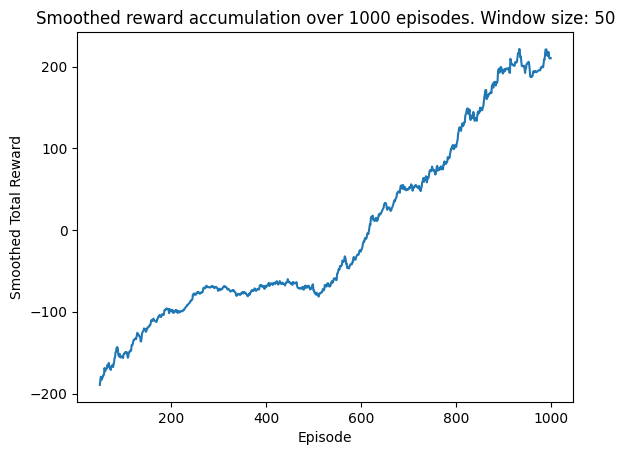

In [5]:
window_size = 50
rolling_rewards = pd.Series(rewards).rolling(window=window_size).mean()
plt.plot(rolling_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed reward accumulation over {N_EPISODES} episodes. Window size: {window_size}")
plt.show()

In [9]:
N_TEST_RUNS = 100
RENDER = None # set to "human" to enable game UI

env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
      enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode = None)
test_reward = 0
for _ in range(N_TEST_RUNS):
  terminated = False
  truncated = False
  state = env.reset()[0]
  while not(terminated or truncated):
    state, r, terminated, truncated, _i = env.step(dql.choose_action(state))
    test_reward += float(r)
print(f"{N_TEST_RUNS} games played")
print(f"Average reward per game: {test_reward/N_TEST_RUNS}")

100 games played
Average reward per game: 234.6202294699098


## Approach 2: A2C

In [ ]:
class Actor(Module):
    def __init__(self, input_dim, action_dim):
        super().__init__()
        self.net = Sequential(
            Linear(input_dim, 256),
            ReLU(),
            Linear(256, 256),
            ReLU(),
            Linear(256, action_dim)
        )
    def forward(self, x):
        return self.net(x)

class Critic(Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = Sequential(
            Linear(input_dim, 256),
            ReLU(),
            Linear(256, 256),
            ReLU(),
            Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


In [72]:
class A2C:
    def __init__(
        self,
        n_envs: int,
        obs_dim: int,
        action_dim: int,
        actor_lr=3e-4,
        critic_lr=1e-4,
        gamma=0.99,
        batch_size=10,
        device="cpu"
    ):
        self.device = device
        self.n_envs = n_envs
        self.gamma = gamma
        self.batch_size = batch_size

        self.actor = Actor(obs_dim, action_dim).to(device)
        self.critic = Critic(obs_dim).to(device)

        self.a_opt = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.c_opt = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)

    def _to_tensor(self, x):
        return torch.tensor(x, dtype=torch.float32, device=self.device)

    def train(self, envs, total_updates=1000):
        states, _ = envs.reset()

        episode_rewards = np.zeros(self.n_envs)
        completed_rewards = []

        for update in range(total_updates):

            # rollout buffers
            states_list = []
            values_list = []
            rewards_list = []
            dones_list = []
            log_probs_list = []
            entropy_list = []

            for _ in range(self.batch_size):
                states_tensor = self._to_tensor(states)

                logits = self.actor(states_tensor)
                dist = Categorical(logits=logits)

                actions = dist.sample()

                next_states, rewards, terms, truncs, _ = envs.step(actions.cpu().numpy())
                dones = np.logical_or(terms, truncs)

                values = self.critic(states_tensor)

                states_list.append(states_tensor)
                values_list.append(values)
                rewards_list.append(self._to_tensor(rewards))
                dones_list.append(self._to_tensor(dones))
                log_probs_list.append(dist.log_prob(actions))
                entropy_list.append(dist.entropy())

                # track episode rewards
                episode_rewards += rewards
                for i, done in enumerate(dones):
                    if done:
                        completed_rewards.append(episode_rewards[i])
                        episode_rewards[i] = 0

                states = next_states

            # stack tensors → (T, N)
            states_t = torch.stack(states_list)
            values_t = torch.stack(values_list)
            rewards_t = torch.stack(rewards_list)
            dones_t = torch.stack(dones_list)
            log_probs_t = torch.stack(log_probs_list)
            entropy_t = torch.stack(entropy_list)

            # bootstrap
            with torch.no_grad():
                last_values = self.critic(self._to_tensor(states))

            returns = torch.zeros_like(values_t)

            R = last_values
            for t in reversed(range(self.batch_size)):
                R = rewards_t[t] + self.gamma * R * (1 - dones_t[t])
                returns[t] = R

            # flatten (T * N)
            T, N = returns.shape
            returns = returns.view(T * N)
            values = values_t.view(T * N)
            log_probs = log_probs_t.view(T * N)
            entropy = entropy_t.view(T * N)

            advantages = returns - values
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

            # losses
            actor_loss = -(log_probs * advantages.detach()).mean()
            critic_loss = advantages.pow(2).mean()
            entropy_bonus = entropy.mean()

            total_loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_bonus

            # optimize
            self.a_opt.zero_grad()
            self.c_opt.zero_grad()

            total_loss.backward()

            self.a_opt.step()
            self.c_opt.step()

            if update % 10 == 0 and len(completed_rewards) > 0:
                print(f"Update {update}, avg reward: {np.mean(completed_rewards[-20:]):.2f}")

        return completed_rewards

    def act(self, state):
        state = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            logits = self.actor(state)
            action = torch.argmax(logits, dim=-1)
        return action.item()

In [74]:
N_EPISODES = 100
N_ENVS = 10

envs = gym.make_vec("LunarLander-v3", num_envs=N_ENVS, continuous=False, gravity=-10.0,
      enable_wind=False, wind_power=15.0, turbulence_power=1.5, render_mode = None)

obs_dim = envs.single_observation_space.shape[0]
action_dim = envs.single_action_space.n

agent = A2C(
    n_envs=N_ENVS,
    obs_dim=obs_dim,
    action_dim=action_dim,
    device="mps" if torch.backends.mps.is_available() else "cpu",
)

rewards = agent.train(envs, total_updates=N_EPISODES)


Update 10, avg reward: -227.36
Update 20, avg reward: -217.05
Update 30, avg reward: -214.39
Update 40, avg reward: -212.55
Update 50, avg reward: -210.54
Update 60, avg reward: -236.14
Update 70, avg reward: -240.13
Update 80, avg reward: -200.11
Update 90, avg reward: -203.30


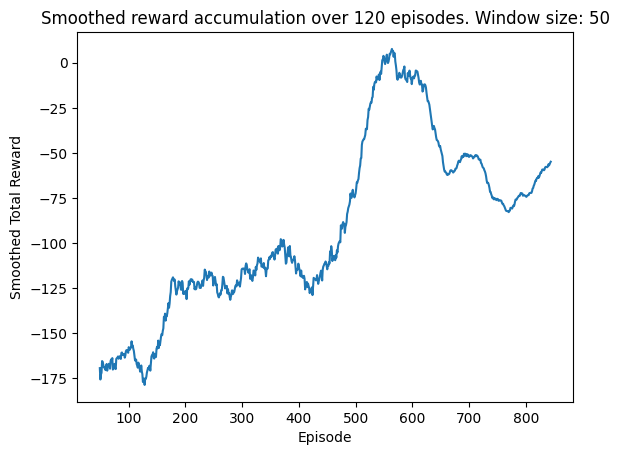

In [62]:
window_size = 50
rolling_rewards = pd.Series(rewards).rolling(window=window_size).mean()
plt.plot(rolling_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title(f"Smoothed reward accumulation over {N_EPISODES} episodes. Window size: {window_size}")
plt.show()